<a href="https://colab.research.google.com/github/prince-bennie/Exam-score-linear-regression/blob/main/landing_page.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

remunaration Landing Pages automation project.

In [22]:
import gspread
from google.colab import auth
auth.authenticate_user()

from google.auth import default
creds, _ = default()

gc = gspread.authorize(creds)

# Open your sheet
sheet = gc.open("LandingPage").sheet1   # Replace with your sheet name
data = sheet.get_all_records()

import pandas as pd
df = pd.DataFrame(data)
df.head()


,DocumentID,Full Name,NIGERIAN BAR ASSOCIATION (Port Harcourt),DEED OF,LAWYER,CONSIDERATION,SIGNED,,DATE
0,C.S. MADUBA 001,REMIGIVSM EZEBUNWA IZUOGU,NIGERIAN BAR ASSOCIATION (Port Harcourt),DEED OF CONVEYANCE Between MR CHIBUIKE UDEAJA ...,PREPARED BY C.S. MADUBA Esq ACIArb(UK). 2007/2...,"CONSIDERATION: N14,000,000. Document authentic...",Mrs Cordelia Eke(branch chairman),,22/12/25


In [14]:
!pip install qrcode[pil]


# Step 1: Authenticate in Colab
import gspread
from google.colab import auth
auth.authenticate_user()

from google.auth import default
creds, _ = default()
gc = gspread.authorize(creds)

import pandas as pd
import qrcode
import os


# Step 2: Open your Google Sheet
sheet = gc.open("LandingPage").sheet1   # Replace with your sheet name
data = sheet.get_all_records()
df = pd.DataFrame(data)

# Step 3: Create folders for outputs
os.makedirs("landing_pages", exist_ok=True)
os.makedirs("qr_codes", exist_ok=True)

# Step 4: Generate HTML + QR for each row
base_url = "prince-bennie.github.io/remunaration-Landing_page.git"  # Replace later with your hosted domain

for i, row in df.iterrows():
    doc_id = row["DocumentID"]
    full_name = row["Full Name"]          # matches your sheet header
                    # adjust to your actual header
    prepared_by = row["LAWYER"]      # matches your sheet header
    consideration = row["CONSIDERATION"]  # adjust to your actual header
    signed = row["SIGNED"]                # adjust to your actual header
    date = row["DATE"]                    # adjust to your actual header


    # --- Generate HTML file ---
    html_content = f"""
    <!DOCTYPE html>
    <html>
    <head>
        <title>Landing Page - {full_name}</title>
    </head>
    <body>
        <h1>Hello, {full_name}!</h1>

        <p>{prepared_by}</p>
        <p>{consideration}</p>
        <p>{signed}</p>
        <p>{date}</p>
    </body>
    </html>
    """
    with open(f"landing_pages/{doc_id}.html", "w", encoding="utf-8") as f:
        f.write(html_content)

    # --- Generate QR code ---
    url = f"{base_url}{doc_id}.html"  # Future hosted URL
    qr = qrcode.make(url)
    qr.save(f"qr_codes/{doc_id}.png")

    print(f"Generated landing page + QR for {doc_id} → {url}")
    print(df.columns.tolist())


!zip -r landing_pages.zip landing_pages






Generated landing page + QR for C.S. MADUBA 001 → prince-bennie.github.io/remunaration-Landing_page.gitC.S. MADUBA 001.html
['DocumentID', 'Full Name', 'NIGERIAN BAR ASSOCIATION (Port Harcourt)', 'DEED OF ', 'LAWYER', 'CONSIDERATION', 'SIGNED', '', 'DATE']
updating: landing_pages/ (stored 0%)
updating: landing_pages/C.S. MADUBA 001.html (deflated 39%)


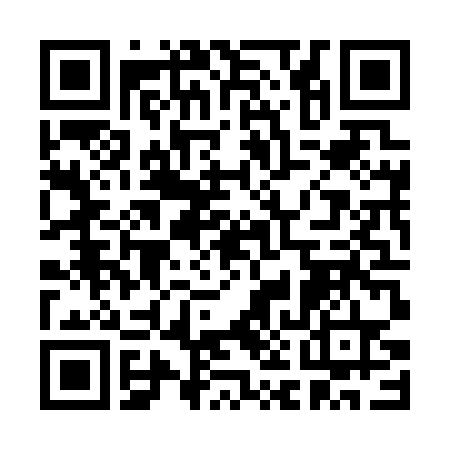

In [15]:
import glob
from IPython.display import Image, display

# Show all QR codes generated
for qr_file in glob.glob("qr_codes/*.png"):
    display(Image(filename=qr_file))


  adding: landing_pages/ (stored 0%)
  adding: landing_pages/C.S. MADUBA 001.html (deflated 42%)
